# EfficientNetV2-S — Random Search for Best Classification Head

This notebook runs a **random search over classification head architectures** while keeping all training configuration **identical to the baseline** for fair comparison.

---

### Strategy

1. Define a search space of head hyperparameters (hidden sizes, layers, dropout, activation, BatchNorm)
2. Sample **20 random configurations**
3. Train each on **1 fold only** (fast screening, ~15 min per config on Colab GPU)
4. Rank by validation accuracy
5. Retrain the **top-3 configs** with full **5-fold CV**
6. Export the winner as a ready-to-use notebook

### Search Space (Head Only)

| Parameter | Values |
|---|---|
| Number of hidden layers | 1, 2, 3 |
| Hidden sizes | 128, 256, 512, 768, 1024 |
| Dropout rate | 0.2, 0.3, 0.4, 0.5 |
| Activation | ReLU, GELU, SiLU |
| BatchNorm | True, False |

### Fixed Training Config (Same as All Baselines)

| Parameter | Value |
|---|---|
| Optimizer | Adam (lr=1e-3, weight_decay=1e-4) |
| LR Scheduler | ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7) |
| Early Stopping | patience=7 |
| Loss | CrossEntropyLoss (balanced class weights) |
| Batch Size | 32 |
| Max Epochs | 30 |

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# COLAB / KAGGLE SETUP — Clone repo & install dependencies
# ══════════════════════════════════════════════════════════════════════════════
import os

REPO_URL    = 'https://github.com/csstudentkaum/KHOTAA.git'
BRANCH      = 'new-start'
REPO_DIR    = '/content/KHOTAA'           # ← /content for Colab, /kaggle/working for Kaggle
WORKING_DIR = os.path.join(REPO_DIR, 'models', 'classification')

if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
    print(f"✓ Cloned {BRANCH} branch → {REPO_DIR}")
else:
    print(f"✓ Repo already exists at {REPO_DIR}")

os.chdir(WORKING_DIR)
print(f"✓ Working directory: {os.getcwd()}")

!pip install roboflow -q
print("✓ Setup complete")

Cloning into '/content/KHOTAA'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 583 (delta 32), reused 36 (delta 25), pack-reused 535 (from 1)
Receiving objects: 100% (583/583), 20.83 MiB | 24.10 MiB/s, done.
Resolving deltas: 100% (277/277), done.
✓ Cloned new-start branch → /content/KHOTAA
✓ Working directory: /content/KHOTAA/models/classification
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.0 MB/s eta 0:00:00
✓ Setup complete


## 1. Imports & Configuration

In [ ]:
import sys, os, random, warnings, json, time, copy
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from datetime import datetime

# ── Reproducibility ─────────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Project imports ─────────────────────────────────────────────────────────────
sys.path.append('../')
sys.path.append('./')

import importlib
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import training_engine
importlib.reload(training_engine)
from utils.training_engine import (
    TrainingEngine, create_optimizer, create_scheduler,
    compute_balanced_class_weights, EarlyStopping
)
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_curve, plot_training_history
)

# ── FIXED Training Config (same as all baselines) ───────────────────────
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 1e-3
N_FOLDS       = 5

# ── Search Config ───────────────────────────────────────────────────────
N_SEARCH_TRIALS  = 20    # number of random configs to try
SEARCH_FOLD      = 1     # use only fold 1 for fast screening
TOP_K            = 3     # retrain top-K with full 5-fold CV

# ── Roboflow Dataset ────────────────────────────────────────────────────
from roboflow import Roboflow
rf = Roboflow(api_key="aOyWN2odFMV7P4HudwVJ")
project = rf.workspace("dfu-o28ut").project("dfu-kew1f-gzodp")
version = project.version(1)
dataset = version.download("folder")
DATASET_PATH = dataset.location + "/"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
print(f"✓ Dataset: {DATASET_PATH}")
print(f"✓ Search: {N_SEARCH_TRIALS} random configs → top-{TOP_K} with full {N_FOLDS}-fold CV")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DFU-1 in folder:: 100%|██████████| 4462/4462 [00:00<00:00, 12026.26it/s]

✓ Device: cuda
✓ Dataset: /content/KHOTAA/models/classification/DFU-1/
✓ Search: 20 random configs → top-3 with full 5-fold CV


## 2. Load Dataset

In [ ]:
# ── Load dataset ─────────────────────────────────────────────────────────────
loader = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes     = loader.get_classes()
num_classes = loader.get_num_classes()

preprocessor       = DFUPreprocessing()
train_transform    = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Compute class weights once
class_weights_tensor = compute_balanced_class_weights(y_all, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"✓ Classes: {classes} ({num_classes})")
print(f"✓ Total samples: {len(X_all)}")
print(f"✓ Class weights: {class_weights_tensor.cpu().numpy()}")

[DatasetLoader] Root: /content/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
[ClassWeights] Balanced class weights: {0: 2.4044471153846154, 1: 0.5856264637002342, 2: 6.5805921052631575, 3: 0.5798550724637681}
✓ Classes: ['Both', 'Infection', 'Ischaemia', 'None'] (4)
✓ Total samples: 4001
✓ Class weights: [2.404447  0.5856265 6.580592  0.5798551]


## 3. Define Search Space & Model Builder

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SEARCH SPACE — only head architecture parameters
# ══════════════════════════════════════════════════════════════════════════════
SEARCH_SPACE = {
    'n_hidden_layers': [1, 2, 3],
    'hidden_sizes':    [128, 256, 512, 768, 1024],
    'dropout':         [0.2, 0.3, 0.4, 0.5],
    'activation':      ['relu', 'gelu', 'silu'],
    'use_batchnorm':   [True, False],
}

ACTIVATION_MAP = {
    'relu': nn.ReLU,
    'gelu': nn.GELU,
    'silu': nn.SiLU,
}


def sample_head_config(rng):
    """Sample a random head configuration."""
    n_layers = int(rng.choice(SEARCH_SPACE['n_hidden_layers']))

    # Sample hidden sizes (decreasing order for a natural funnel shape)
    hidden_sizes = sorted([int(x) for x in rng.choice(
        SEARCH_SPACE['hidden_sizes'],
        size=n_layers,
        replace=True
    )], reverse=True)

    config = {
        'n_hidden_layers': n_layers,
        'hidden_sizes':    hidden_sizes,
        'dropout':         float(rng.choice(SEARCH_SPACE['dropout'])),
        'activation':      str(rng.choice(SEARCH_SPACE['activation'])),
        'use_batchnorm':   bool(rng.choice(SEARCH_SPACE['use_batchnorm'])),
    }
    return config


def config_to_str(cfg):
    """Short string summary of a config."""
    sizes = '→'.join(str(s) for s in cfg['hidden_sizes'])
    bn = 'BN' if cfg['use_batchnorm'] else 'noBN'
    return f"{sizes} | drop={cfg['dropout']} | {cfg['activation']} | {bn}"


class EfficientNetV2SSearchable(nn.Module):
    """
    EfficientNetV2-S with a configurable classification head.
    Backbone is always ImageNet-pretrained and fully trainable.
    """
    def __init__(self, head_config, num_classes=4, pretrained=True):
        super().__init__()

        if pretrained:
            backbone = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        else:
            backbone = models.efficientnet_v2_s(weights=None)

        self.features = backbone.features
        self.avgpool  = backbone.avgpool

        # Build classification head from config
        act_fn = ACTIVATION_MAP[head_config['activation']]
        layers = [nn.Flatten()]

        in_features = 1280  # EfficientNetV2-S output
        for h_size in head_config['hidden_sizes']:
            layers.append(nn.Linear(in_features, h_size))
            if head_config['use_batchnorm']:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(act_fn())
            layers.append(nn.Dropout(head_config['dropout']))
            in_features = h_size

        layers.append(nn.Linear(in_features, num_classes))
        self.classifier = nn.Sequential(*layers)

        # Kaiming init on head
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

        self.head_config = head_config

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


# ── Generate all search configs ─────────────────────────────────────────────
rng = np.random.RandomState(SEED)

# Always include the baseline config (single linear layer) for reference
baseline_config = {
    'n_hidden_layers': 0,
    'hidden_sizes':    [],
    'dropout':         0.2,
    'activation':      'relu',
    'use_batchnorm':   False,
}

search_configs = [baseline_config]  # config #0 = baseline reference

# Generate unique random configs
seen = set()
seen.add(json.dumps(baseline_config, sort_keys=True))

while len(search_configs) < N_SEARCH_TRIALS + 1:  # +1 for baseline
    cfg = sample_head_config(rng)
    key = json.dumps(cfg, sort_keys=True)
    if key not in seen:
        seen.add(key)
        search_configs.append(cfg)

print(f"✓ Generated {len(search_configs)} configs ({N_SEARCH_TRIALS} random + 1 baseline)")
print(f"\nConfig #0 (BASELINE): {config_to_str(baseline_config)}")
for i, cfg in enumerate(search_configs[1:], 1):
    print(f"Config #{i}: {config_to_str(cfg)}")

✓ Generated 21 configs (20 random + 1 baseline)

Config #0 (BASELINE):  | drop=0.2 | relu | noBN
Config #1: 1024→768→512 | drop=0.5 | relu | BN
Config #2: 512→512→256 | drop=0.4 | relu | noBN
Config #3: 1024→768→256 | drop=0.3 | gelu | noBN
Config #4: 128 | drop=0.5 | gelu | noBN
Config #5: 768 | drop=0.2 | relu | BN
Config #6: 768→768→256 | drop=0.5 | silu | noBN
Config #7: 768→512 | drop=0.4 | relu | BN
Config #8: 512 | drop=0.4 | relu | BN
Config #9: 768→256→128 | drop=0.5 | gelu | noBN
Config #10: 256→128 | drop=0.2 | gelu | noBN
Config #11: 1024→768→768 | drop=0.5 | silu | BN
Config #12: 768→128 | drop=0.3 | gelu | noBN
Config #13: 768→256 | drop=0.3 | relu | BN
Config #14: 768→256 | drop=0.3 | gelu | noBN
Config #15: 768→128 | drop=0.3 | relu | noBN
Config #16: 256 | drop=0.4 | relu | noBN
Config #17: 768→128 | drop=0.5 | relu | BN
Config #18: 1024 | drop=0.2 | relu | BN
Config #19: 128 | drop=0.5 | silu | BN
Config #20: 512→512→128 | drop=0.2 | silu | BN


## 4. Phase 1 — Fast Screening (1-Fold per Config)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1: Train each config on FOLD 1 only (fast screening)
# ══════════════════════════════════════════════════════════════════════════════

# Get fold 1 split
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[0]  # fold 1

X_train_fold = X_all[train_idx]
y_train_fold = y_all[train_idx]
X_val_fold   = X_all[val_idx]
y_val_fold   = y_all[val_idx]

train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
val_dataset   = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Fold 1: {len(X_train_fold)} train / {len(X_val_fold)} val")

# ── Train each config ──────────────────────────────────────────────────────
search_results = []

for trial_idx, cfg in enumerate(search_configs):
    trial_start = time.time()
    is_baseline = (trial_idx == 0)
    tag = "BASELINE" if is_baseline else f"Trial {trial_idx}"

    print(f"\n{'='*70}")
    print(f"[{tag}] {config_to_str(cfg)}")
    print(f"{'='*70}")

    # ── Create model ─────────────────────────────────────────────────────
    if is_baseline:
        # Use standard EfficientNetV2-S (single linear head)
        model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        model = EfficientNetV2SSearchable(cfg, num_classes=num_classes, pretrained=True)

    model = model.to(device)

    # ── SAME training config as all baselines ────────────────────────────
    optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                                 gamma=0.3, patience=3, min_lr=1e-7)
    engine = TrainingEngine(model=model, device=device)
    early_stopper = EarlyStopping(patience=7, verbose=False)

    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_epoch = 0
    best_state = None
    stopped_epoch = EPOCHS

    for epoch in range(EPOCHS):
        print(f"\n  {'─'*50}")
        print(f"  Epoch {epoch+1}/{EPOCHS}")
        print(f"  {'─'*50}")

        # Train
        train_loss, train_acc = engine.train_epoch(train_loader, criterion, optimizer)

        # Validate
        val_loss, val_acc, val_preds, val_labels, _ = engine.evaluate(
            val_loader, criterion, measure_inference_time=False)

        # Update learning rate
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Print epoch results
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
        print(f"  LR: {current_lr:.2e}")

        # Save best model state
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            print(f"  ✓ New best model! Val Acc: {val_acc*100:.2f}%")

        # Check early stopping
        if early_stopper(val_loss, epoch + 1):
            stopped_epoch = epoch + 1
            print(f"\n  {'='*50}")
            print(f"  Early stopping at epoch {epoch+1}/{EPOCHS}")
            print(f"  Best Val Acc: {best_val_acc*100:.2f}%")
            print(f"  {'='*50}")
            break
    else:
        stopped_epoch = EPOCHS
        print(f"\n  {'='*50}")
        print(f"  Training complete — all {EPOCHS} epochs")
        print(f"  Best Val Acc: {best_val_acc*100:.2f}%")
        print(f"  {'='*50}")

    # Compute macro F1 with best model
    model.load_state_dict(best_state)
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs.to(device))
            all_p.append(torch.max(outputs, 1)[1].cpu().numpy())
            all_l.append(labels.numpy())
    preds_np  = np.concatenate(all_p)
    labels_np = np.concatenate(all_l)
    macro_f1 = f1_score(labels_np, preds_np, average='macro')

    elapsed = time.time() - trial_start

    head_params = sum(p.numel() for p in model.classifier.parameters()
                      ) if hasattr(model, 'classifier') else 0

    result = {
        'trial': trial_idx,
        'config': cfg,
        'config_str': config_to_str(cfg),
        'best_val_acc': best_val_acc,
        'best_val_loss': best_val_loss,
        'macro_f1': macro_f1,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped_epoch,
        'time_seconds': elapsed,
        'head_params': head_params,
        'is_baseline': is_baseline,
    }
    search_results.append(result)

    print(f"\n  ► SUMMARY: Val Acc: {best_val_acc*100:.2f}% | Macro F1: {macro_f1*100:.2f}% | "
          f"Best@{best_epoch} | Stopped@{stopped_epoch} | {elapsed/60:.1f}min")

    # Show running leaderboard
    if len(search_results) > 1:
        sorted_so_far = sorted(search_results, key=lambda x: x['best_val_acc'], reverse=True)
        print(f"\n  Leaderboard ({len(search_results)}/{len(search_configs)} done):")
        for rank, sr in enumerate(sorted_so_far[:3], 1):
            marker = " ← current" if sr['trial'] == trial_idx else ""
            bl = " (BASELINE)" if sr['is_baseline'] else ""
            print(f"     #{rank}: Trial {sr['trial']}{bl} — {sr['best_val_acc']*100:.2f}%{marker}")

    del model, optimizer, scheduler, engine, best_state
    torch.cuda.empty_cache()

print(f"\n{'='*70}")
print(f"PHASE 1 COMPLETE — {len(search_results)} configs evaluated")
print(f"Total time: {sum(r['time_seconds'] for r in search_results)/60:.1f} minutes")
print(f"{'='*70}")

Fold 1: 3200 train / 801 val

[BASELINE]  | drop=0.2 | relu | noBN
Created Adam optimizer: lr=0.001, weight_decay=0.0001
Created ReduceLROnPlateau scheduler: mode=min, patience=3, factor=0.3, min_lr=1e-07
Training on: cuda

  ──────────────────────────────────────────────────
  Epoch 1/30
  ──────────────────────────────────────────────────


Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.39it/s, loss=0.1943, acc=56.30%]


  Train Loss: 1.0727 | Train Acc: 52.94%
  Val Loss:   0.9582 | Val Acc:   56.30%
  LR: 1.00e-03
  ✓ New best model! Val Acc: 56.30%

  ──────────────────────────────────────────────────
  Epoch 2/30
  ──────────────────────────────────────────────────


Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.88it/s, loss=0.5087, acc=63.80%]


  Train Loss: 0.9156 | Train Acc: 61.91%
  Val Loss:   0.8754 | Val Acc:   63.80%
  LR: 1.00e-03
  ✓ New best model! Val Acc: 63.80%

  ──────────────────────────────────────────────────
  Epoch 3/30
  ──────────────────────────────────────────────────


...

Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.66it/s, loss=0.8585, acc=54.93%]


  Train Loss: 1.3846 | Train Acc: 47.59%
  Val Loss:   1.0611 | Val Acc:   54.93%
  LR: 3.00e-04

  ──────────────────────────────────────────────────
  Epoch 13/30
  ──────────────────────────────────────────────────


Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.70it/s, loss=0.9013, acc=56.55%]

  Train Loss: 1.2983 | Train Acc: 47.25%
  Val Loss:   1.0179 | Val Acc:   56.55%
  LR: 3.00e-04

  Early stopping at epoch 13/30
  Best Val Acc: 57.18%



  ► SUMMARY: Val Acc: 57.18% | Macro F1: 52.62% | Best@11 | Stopped@13 | 10.3min

  Leaderboard (21/21 done):
     #1: Trial 14 — 86.52%
     #2: Trial 3 — 85.89%
     #3: Trial 4 — 85.02%

PHASE 1 COMPLETE — 21 configs evaluated
Total time: 307.7 minutes


## 5. Phase 1 Results — Ranking


PHASE 1 RESULTS — RANKED BY VALIDATION ACCURACY (Fold 1)
      Trial                                 Config  Val Acc (%)  Macro F1 (%)  Best Epoch  Stopped     Time (s)  Head Params  Baseline
Rank                                                                                                                                  
1        14       768→256 | drop=0.3 | gelu | noBN    86.516854     88.194668          19       19   907.985159      1181700     False
2         3  1024→768→256 | drop=0.3 | gelu | noBN    85.892634     86.114989          21       22  1046.257033      2296836     False
3         4           128 | drop=0.5 | gelu | noBN    85.018727     87.586702          25       25  1185.061719       164484     False
4        12       768→128 | drop=0.3 | gelu | noBN    83.395755     85.158571          19       19   905.650231      1082756     False
5        10       256→128 | drop=0.2 | gelu | noBN    83.395755     87.126977          19       20   952.447027       361348     Fal

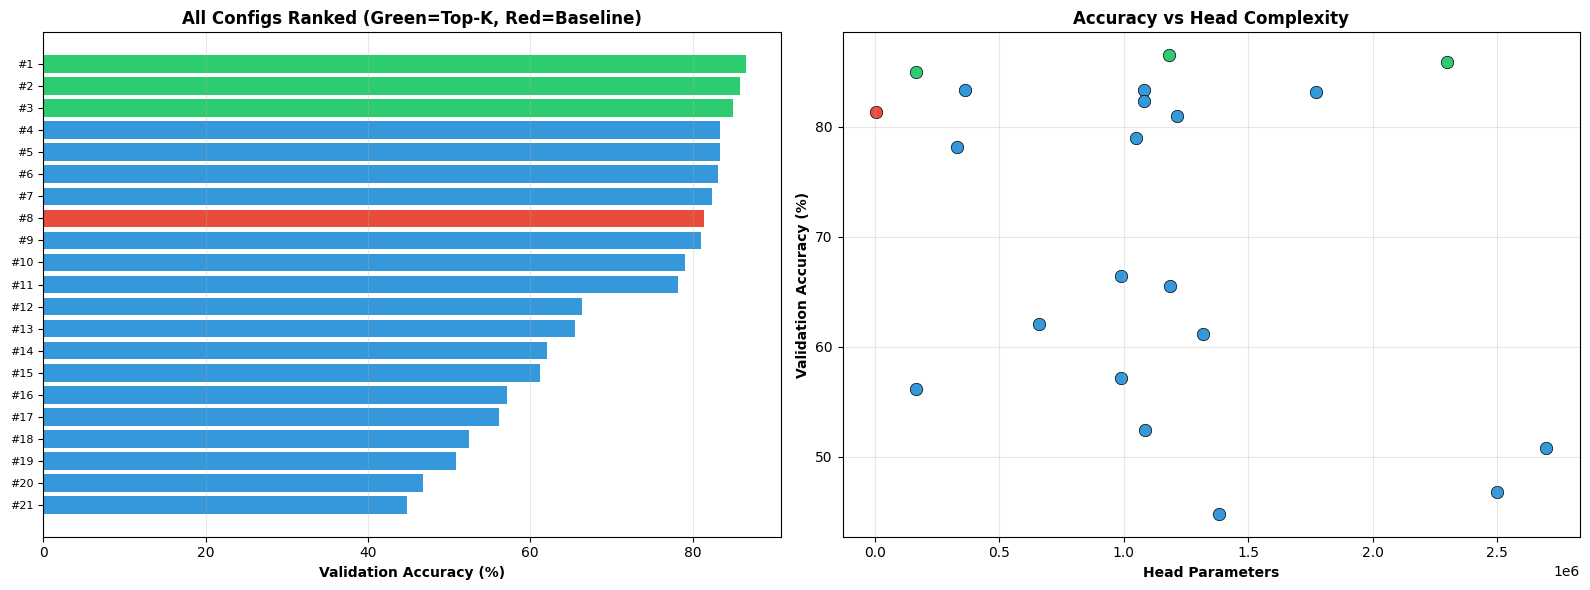

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RANK ALL CONFIGS
# ══════════════════════════════════════════════════════════════════════════════
df = pd.DataFrame([
    {
        'Trial': r['trial'],
        'Config': r['config_str'],
        'Val Acc (%)': r['best_val_acc'] * 100,
        'Macro F1 (%)': r['macro_f1'] * 100,
        'Best Epoch': r['best_epoch'],
        'Stopped': r['stopped_epoch'],
        'Time (s)': r['time_seconds'],
        'Head Params': r['head_params'],
        'Baseline': r['is_baseline'],
    }
    for r in search_results
])

df_sorted = df.sort_values('Val Acc (%)', ascending=False).reset_index(drop=True)
df_sorted.index = df_sorted.index + 1  # 1-based ranking
df_sorted.index.name = 'Rank'

print("\n" + "="*90)
print("PHASE 1 RESULTS — RANKED BY VALIDATION ACCURACY (Fold 1)")
print("="*90)
print(df_sorted.to_string())

# Highlight baseline position
baseline_rank = df_sorted[df_sorted['Baseline'] == True].index[0]
baseline_acc  = df_sorted.loc[baseline_rank, 'Val Acc (%)']
print(f"\n→ Baseline (single Linear head) is ranked #{baseline_rank} with {baseline_acc:.2f}% accuracy")

# Show top-K for Phase 2
top_k_trials = df_sorted.head(TOP_K)['Trial'].tolist()
print(f"\n→ TOP-{TOP_K} configs for Phase 2 (full 5-fold CV): Trials {top_k_trials}")
for rank, row in df_sorted.head(TOP_K).iterrows():
    print(f"  #{rank}: Trial {int(row['Trial'])} — {row['Val Acc (%)']:.2f}% — {row['Config']}")

# ── Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: Val Acc by config
colors = ['#2ecc71' if t in top_k_trials else '#e74c3c' if r['is_baseline'] else '#3498db'
          for r in search_results for t in [r['trial']]]
ax = axes[0]
bars = ax.barh(range(len(df_sorted)), df_sorted['Val Acc (%)'].values, color=
    ['#2ecc71' if int(row['Trial']) in top_k_trials
     else '#e74c3c' if row['Baseline']
     else '#3498db'
     for _, row in df_sorted.iterrows()])
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels([f"#{i}" for i in df_sorted.index], fontsize=8)
ax.set_xlabel('Validation Accuracy (%)', fontweight='bold')
ax.set_title('All Configs Ranked (Green=Top-K, Red=Baseline)', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Scatter: Val Acc vs Head Params
ax = axes[1]
for _, row in df_sorted.iterrows():
    c = '#2ecc71' if int(row['Trial']) in top_k_trials else '#e74c3c' if row['Baseline'] else '#3498db'
    ax.scatter(row['Head Params'], row['Val Acc (%)'], c=c, s=80, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Head Parameters', fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontweight='bold')
ax.set_title('Accuracy vs Head Complexity', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Phase 2 — Full 5-Fold CV on Top Configs

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2: Full 5-Fold CV on the top-K configs
# ══════════════════════════════════════════════════════════════════════════════

phase2_results = []

for rank_idx, trial_id in enumerate(top_k_trials):
    cfg = search_results[trial_id]['config']
    is_baseline = search_results[trial_id]['is_baseline']
    tag = f"Config #{trial_id}" + (" (BASELINE)" if is_baseline else "")

    print(f"\n{'#'*70}")
    print(f"PHASE 2 [{rank_idx+1}/{TOP_K}] — {tag}")
    print(f"Head: {config_to_str(cfg)}")
    print(f"{'#'*70}")

    fold_accs = []
    fold_f1s  = []
    fold_epochs = []
    best_overall_acc   = 0.0
    best_overall_state = None

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
        print(f"\n  {'='*60}")
        print(f"  Fold {fold}/{N_FOLDS}")
        print(f"  {'='*60}")

        train_ds = DFUDataset(X_all[train_idx], y_all[train_idx], transform=train_transform)
        val_ds   = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
        train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_ld   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        # Create model
        if is_baseline:
            model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        else:
            model = EfficientNetV2SSearchable(cfg, num_classes=num_classes, pretrained=True)
        model = model.to(device)

        # SAME training config
        optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)
        scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                                     gamma=0.3, patience=3, min_lr=1e-7)
        engine = TrainingEngine(model=model, device=device)
        early_stopper = EarlyStopping(patience=7, verbose=False)

        fold_best_acc = 0.0
        fold_best_state = None

        for epoch in range(EPOCHS):
            print(f"\n    {'─'*50}")
            print(f"    Epoch {epoch+1}/{EPOCHS}")
            print(f"    {'─'*50}")

            train_loss, train_acc = engine.train_epoch(train_ld, criterion, optimizer)
            val_loss, val_acc, _, _, _ = engine.evaluate(val_ld, criterion, measure_inference_time=False)

            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
            current_lr = optimizer.param_groups[0]['lr']

            print(f"    Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
            print(f"    Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
            print(f"    LR: {current_lr:.2e}")

            if val_acc > fold_best_acc:
                fold_best_acc = val_acc
                fold_best_state = copy.deepcopy(model.state_dict())
                print(f"    ✓ New best model! Val Acc: {val_acc*100:.2f}%")

            if early_stopper(val_loss, epoch + 1):
                print(f"\n    {'='*50}")
                print(f"    Early stopping at epoch {epoch+1}/{EPOCHS}")
                print(f"    Best Val Acc: {fold_best_acc*100:.2f}%")
                print(f"    {'='*50}")
                break
        else:
            print(f"\n    {'='*50}")
            print(f"    Training complete — all {EPOCHS} epochs")
            print(f"    Best Val Acc: {fold_best_acc*100:.2f}%")
            print(f"    {'='*50}")

        stopped_at = epoch + 1

        # Compute fold macro F1
        model.load_state_dict(fold_best_state)
        model.eval()
        fp, fl = [], []
        with torch.no_grad():
            for inp, lbl in val_ld:
                out = model(inp.to(device))
                fp.append(torch.max(out, 1)[1].cpu().numpy())
                fl.append(lbl.numpy())
        fold_f1 = f1_score(np.concatenate(fl), np.concatenate(fp), average='macro')

        fold_accs.append(fold_best_acc)
        fold_f1s.append(fold_f1)
        fold_epochs.append(stopped_at)

        if fold_best_acc > best_overall_acc:
            best_overall_acc = fold_best_acc
            best_overall_state = copy.deepcopy(fold_best_state)

        print(f"\n  ► Fold {fold} Summary: Acc={fold_best_acc*100:.2f}% | F1={fold_f1*100:.2f}% | Stopped@{stopped_at}")

        del model, optimizer, scheduler, engine
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_accs)
    std_acc  = np.std(fold_accs)
    mean_f1  = np.mean(fold_f1s)
    std_f1   = np.std(fold_f1s)

    phase2_results.append({
        'trial': trial_id,
        'config': cfg,
        'config_str': config_to_str(cfg),
        'is_baseline': is_baseline,
        'mean_acc': mean_acc,
        'std_acc': std_acc,
        'mean_f1': mean_f1,
        'std_f1': std_f1,
        'fold_accs': fold_accs,
        'fold_f1s': fold_f1s,
        'fold_epochs': fold_epochs,
        'best_state': best_overall_state,
    })

    print(f"\n  {'#'*60}")
    print(f"  5-FOLD CV RESULT — {tag}")
    print(f"  Mean Acc: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
    print(f"  Mean F1:  {mean_f1*100:.2f}% ± {std_f1*100:.2f}%")
    print(f"  Folds:    {[f'{a*100:.1f}%' for a in fold_accs]}")
    print(f"  Epochs:   {fold_epochs}")
    print(f"  {'#'*60}")

print(f"\n{'='*70}")
print("PHASE 2 COMPLETE")
print(f"{'='*70}")


######################################################################
PHASE 2 [1/3] — Config #14
Head: 768→256 | drop=0.3 | gelu | noBN
######################################################################

  Fold 1/5
Created Adam optimizer: lr=0.001, weight_decay=0.0001
Created ReduceLROnPlateau scheduler: mode=min, patience=3, factor=0.3, min_lr=1e-07
Training on: cuda

    ──────────────────────────────────────────────────
    Epoch 1/30
    ──────────────────────────────────────────────────


Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.91it/s, loss=0.2944, acc=65.79%]


    Train Loss: 2.9673 | Train Acc: 46.84%
    Val Loss:   1.5483 | Val Acc:   65.79%
    LR: 1.00e-03
    ✓ New best model! Val Acc: 65.79%

    ──────────────────────────────────────────────────
    Epoch 2/30
    ──────────────────────────────────────────────────


Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.49it/s, loss=0.0456, acc=69.66%]


    Train Loss: 1.2843 | Train Acc: 55.50%
    Val Loss:   0.8227 | Val Acc:   69.66%
    LR: 1.00e-03
    ✓ New best model! Val Acc: 69.66%

    ──────────────────────────────────────────────────
    Epoch 3/30
    ──────────────────────────────────────────────────


...

    Train Loss: 0.0837 | Train Acc: 95.85%
    Val Loss:   0.6451 | Val Acc:   82.88%
    LR: 9.00e-05

    ──────────────────────────────────────────────────
    Epoch 29/30
    ──────────────────────────────────────────────────


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  7.13it/s, loss=0.0385, acc=85.00%]


    Train Loss: 0.0790 | Train Acc: 95.91%
    Val Loss:   0.6126 | Val Acc:   85.00%
    LR: 2.70e-05

    ──────────────────────────────────────────────────
    Epoch 30/30
    ──────────────────────────────────────────────────


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  6.89it/s, loss=0.0850, acc=87.25%]


    Train Loss: 0.0716 | Train Acc: 96.84%
    Val Loss:   0.5692 | Val Acc:   87.25%
    LR: 2.70e-05
    ✓ New best model! Val Acc: 87.25%

    Training complete — all 30 epochs
    Best Val Acc: 87.25%

  ► Fold 5 Summary: Acc=87.25% | F1=86.49% | Stopped@30

  ############################################################
  5-FOLD CV RESULT — Config #4
  Mean Acc: 83.43% ± 2.90%
  Mean F1:  84.31% ± 1.82%
  Folds:    ['82.6%', '83.8%', '85.0%', '78.5%', '87.2%']
  Epochs:   [17, 20, 30, 18, 30]
  ############################################################

PHASE 2 COMPLETE


## 7. Final Results & Winner


FINAL 5-FOLD CV RESULTS

Rank  Trial   Mean Acc          Mean F1           Config
------------------------------------------------------------------------------------------
1     4       83.43% ± 2.90%   84.31% ± 1.82%   128 | drop=0.5 | gelu | noBN ★ WINNER
2     3       82.98% ± 4.04%   83.81% ± 4.15%   1024→768→256 | drop=0.3 | gelu | noBN
3     14      82.58% ± 2.91%   83.01% ± 2.59%   768→256 | drop=0.3 | gelu | noBN

★ WINNER: Trial 4
  Head Config  : 128 | drop=0.5 | gelu | noBN
  5-Fold Acc   : 83.43% ± 2.90%
  5-Fold F1    : 84.31% ± 1.82%
  Fold Accs    : ['82.65%', '83.75%', '85.00%', '78.50%', '87.25%']
  Fold Epochs  : [17, 20, 30, 18, 30]

── Copy this config into your notebook ──

WINNING_HEAD_CONFIG = {
  "n_hidden_layers": 1,
  "hidden_sizes": [
    128
  ],
  "dropout": 0.5,
  "activation": "gelu",
  "use_batchnorm": false
}


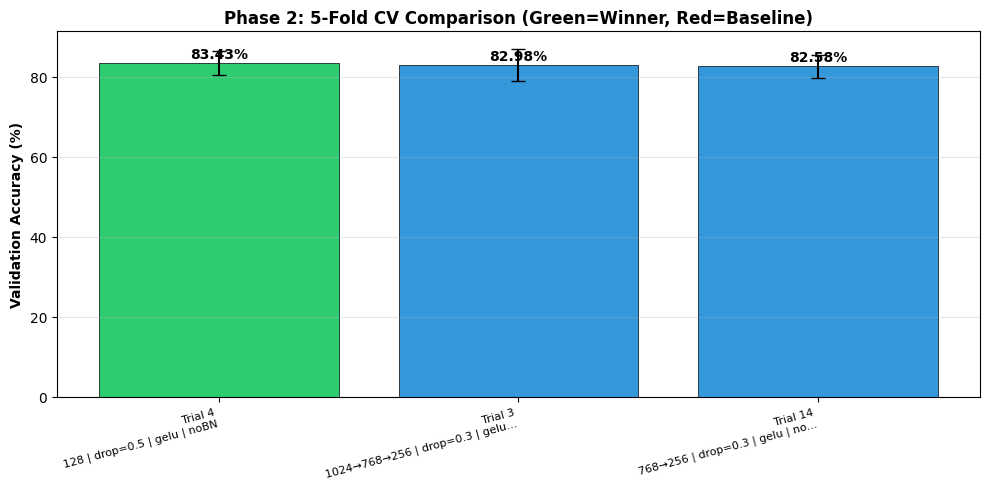

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL COMPARISON — Phase 2 results
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FINAL 5-FOLD CV RESULTS")
print("="*80)

# Sort by mean accuracy
phase2_sorted = sorted(phase2_results, key=lambda x: x['mean_acc'], reverse=True)

print(f"\n{'Rank':<6}{'Trial':<8}{'Mean Acc':<18}{'Mean F1':<18}{'Config'}")
print("-"*90)
for rank, r in enumerate(phase2_sorted, 1):
    tag = " ← BASELINE" if r['is_baseline'] else ""
    tag += " ★ WINNER" if rank == 1 else ""
    print(f"{rank:<6}{r['trial']:<8}"
          f"{r['mean_acc']*100:.2f}% ± {r['std_acc']*100:.2f}%{'':>3}"
          f"{r['mean_f1']*100:.2f}% ± {r['std_f1']*100:.2f}%{'':>3}"
          f"{r['config_str']}{tag}")

# Winner
winner = phase2_sorted[0]
print(f"\n{'='*80}")
print(f"★ WINNER: Trial {winner['trial']}")
print(f"  Head Config  : {winner['config_str']}")
print(f"  5-Fold Acc   : {winner['mean_acc']*100:.2f}% ± {winner['std_acc']*100:.2f}%")
print(f"  5-Fold F1    : {winner['mean_f1']*100:.2f}% ± {winner['std_f1']*100:.2f}%")
print(f"  Fold Accs    : {[f'{a*100:.2f}%' for a in winner['fold_accs']]}")
print(f"  Fold Epochs  : {winner['fold_epochs']}")
print(f"{'='*80}")

# Print the winning config as code
print(f"\n── Copy this config into your notebook ──")
print(f"")
print(f"WINNING_HEAD_CONFIG = {json.dumps(winner['config'], indent=2)}")

# ── Visualization ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

labels = [f"Trial {r['trial']}\n{r['config_str'][:30]}..." if len(r['config_str']) > 30
          else f"Trial {r['trial']}\n{r['config_str']}"
          for r in phase2_sorted]
means  = [r['mean_acc']*100 for r in phase2_sorted]
stds   = [r['std_acc']*100 for r in phase2_sorted]
colors = ['#2ecc71' if i == 0 else '#e74c3c' if r['is_baseline'] else '#3498db'
          for i, r in enumerate(phase2_sorted)]

bars = ax.bar(range(len(means)), means, yerr=stds, capsize=5,
              color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Validation Accuracy (%)', fontweight='bold')
ax.set_title('Phase 2: 5-Fold CV Comparison (Green=Winner, Red=Baseline)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{mean:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Save All Results

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE RESULTS (Phase 1 + Phase 2 + Winner config — NO test metrics)
# ══════════════════════════════════════════════════════════════════════════════
results_dir = 'results/efficientnetv2s_best'
os.makedirs(results_dir, exist_ok=True)

# Phase 1 results
phase1_export = []
for r in search_results:
    phase1_export.append({
        'trial': r['trial'],
        'config': r['config'],
        'config_str': r['config_str'],
        'val_acc': r['best_val_acc'],
        'macro_f1': r['macro_f1'],
        'best_epoch': r['best_epoch'],
        'stopped_epoch': r['stopped_epoch'],
        'time_seconds': r['time_seconds'],
        'is_baseline': r['is_baseline'],
    })

# Phase 2 results
phase2_export = []
for r in phase2_results:
    phase2_export.append({
        'trial': r['trial'],
        'config': r['config'],
        'config_str': r['config_str'],
        'is_baseline': r['is_baseline'],
        'mean_acc': r['mean_acc'],
        'std_acc': r['std_acc'],
        'mean_f1': r['mean_f1'],
        'std_f1': r['std_f1'],
        'fold_accs': r['fold_accs'],
        'fold_f1s': r['fold_f1s'],
        'fold_epochs': r['fold_epochs'],
    })

all_results = {
    'search_config': {
        'n_search_trials': N_SEARCH_TRIALS,
        'search_fold': SEARCH_FOLD,
        'top_k': TOP_K,
        'search_space': {k: [str(v) for v in vals] if isinstance(vals[0], bool) else vals
                         for k, vals in SEARCH_SPACE.items()},
        'training_config': {
            'optimizer': 'Adam', 'lr': LEARNING_RATE, 'weight_decay': 1e-4,
            'scheduler': 'ReduceLROnPlateau', 'epochs': EPOCHS,
            'early_stopping_patience': 7, 'batch_size': BATCH_SIZE,
        }
    },
    'phase1_results': phase1_export,
    'phase2_results': phase2_export,
    'winner': {
        'trial': winner['trial'],
        'config': winner['config'],
        'config_str': winner['config_str'],
        'mean_acc': winner['mean_acc'],
        'std_acc': winner['std_acc'],
        'mean_f1': winner['mean_f1'],
        'std_f1': winner['std_f1'],
    },
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'pytorch_version': torch.__version__,
        'seed': SEED,
    }
}

with open(f'{results_dir}/head_search_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"✓ Results saved → {results_dir}/head_search_results.json")
print(f"\n★ WINNING CONFIG (copy this):")
print(f"")
print(json.dumps(winner['config'], indent=2))

✓ Results saved → results/efficientnetv2s_best/head_search_results.json

★ WINNING CONFIG (copy this):

{
  "n_hidden_layers": 1,
  "hidden_sizes": [
    128
  ],
  "dropout": 0.5,
  "activation": "gelu",
  "use_batchnorm": false
}


## 9. Zip Results for Download

In [11]:
# ── Zip results for download ─────────────────────────────────────────────────
import shutil

zip_output = f'/content/efficientnetv2s_best_results'
shutil.make_archive(zip_output, 'zip', results_dir)
print(f"✓ Zipped → {zip_output}.zip")
print(f"  Size: {os.path.getsize(zip_output + '.zip') / 1024:.1f} KB")

from IPython.display import FileLink
FileLink(f'{zip_output}.zip')

✓ Zipped → /content/efficientnetv2s_best_results.zip
  Size: 2.5 KB


/content/efficientnetv2s_best_results.zip

## 10. Quick Test Peek (Optional — DELETE before final submission)

> **This cell is for your eyes only.** It evaluates the winner's best-fold model on the test set so you can sanity-check results. It does NOT affect any saved results above. Delete this section whenever you're done peeking.

TEST PEEK — Winning Config (Trial 4)
Head: 128 | drop=0.5 | gelu | noBN
[DatasetLoader] Split 'test': 445 images
Test samples: 445

            EfficientNetV2-S Best Head — Test Set Metrics             

Overall Performance Metrics:
   Accuracy:    86.29%
   Precision:   89.04% (PPV - Positive Predictive Value)
   Recall:      88.42% (Sensitivity/TPR)
   Sensitivity: 88.42% (True Positive Rate)
   Specificity: 94.15% (True Negative Rate)
   F1-Score:    88.58% (F-Measure)
   MCC:         0.7799 (Matthews Correlation Coefficient)
   AUC-ROC:     0.9678 (Area Under Curve)

Metric Formulas:
   Precision (PPV) = TP / (TP + FP)
   Recall (Sensitivity) = TP / (TP + FN)
   Specificity = TN / (TN + FP)
   F1-Score = 2PR / (P + R)
   MCC = (TP×TN - FP×FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN))

Per-Class Detailed Metrics:

   Both:
      Precision (PPV):  90.91%
      Recall:           88.89%
      Sensitivity (TPR): 88.89%
      Specificity (TNR): 99.00%
      F1-Score:         89.89%

   Infection

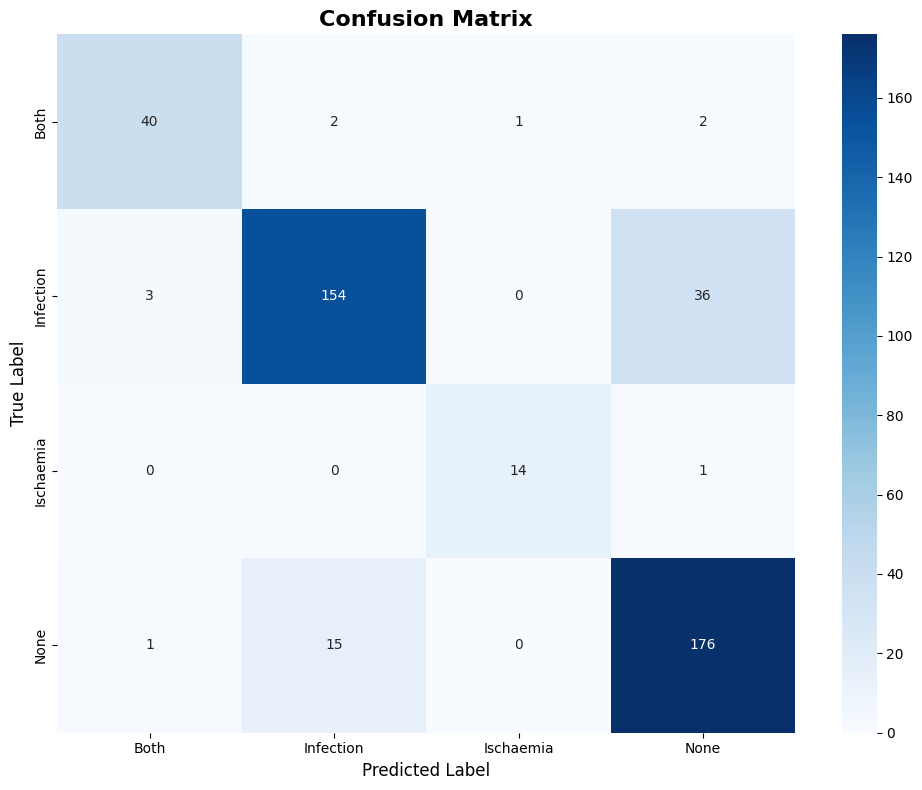

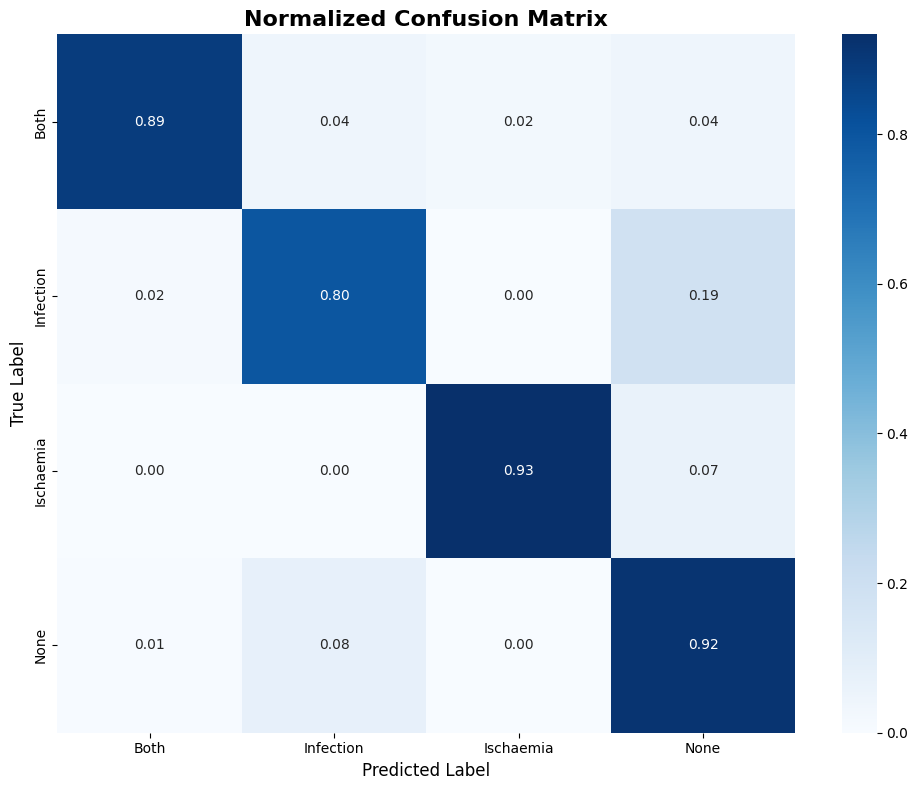

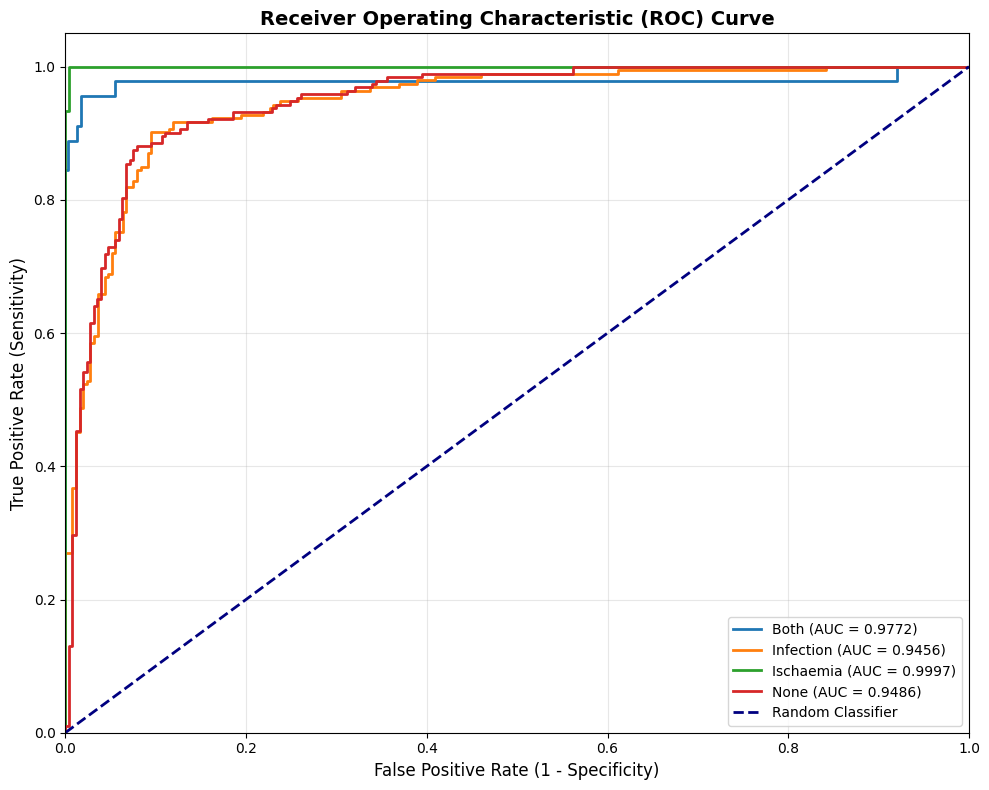


              precision    recall  f1-score   support

        Both     0.9091    0.8889    0.8989        45
   Infection     0.9006    0.7979    0.8462       193
   Ischaemia     0.9333    0.9333    0.9333        15
        None     0.8186    0.9167    0.8649       192

    accuracy                         0.8629       445
   macro avg     0.8904    0.8842    0.8858       445
weighted avg     0.8672    0.8629    0.8625       445


⚠ REMINDER: This is a peek only. Delete this cell before final submission.
   The final test should use a model retrained on ALL train+val data.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# QUICK TEST PEEK — Delete this cell + the markdown above when done
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report

winner_cfg = winner['config']
best_model_state = winner['best_state']

print("="*60)
print(f"TEST PEEK — Winning Config (Trial {winner['trial']})")
print(f"Head: {config_to_str(winner_cfg)}")
print("="*60)

# Load test data
X_test, y_test = loader.load_split_paths('test')
print(f"Test samples: {len(X_test)}")

test_dataset = DFUDataset(X_test, y_test, transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Load best model
if winner['is_baseline']:
    model = models.efficientnet_v2_s(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
else:
    model = EfficientNetV2SSearchable(winner_cfg, num_classes=num_classes, pretrained=False)
model.load_state_dict(best_model_state)
model = model.to(device).eval()

# Predict (collect probabilities too for AUC/ROC)
test_preds, test_labels_arr, test_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        test_probs.append(probs.cpu().numpy())
        test_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        test_labels_arr.append(labels.numpy())

test_preds      = np.concatenate(test_preds)
test_labels_arr = np.concatenate(test_labels_arr)
y_pred_proba    = np.vstack(test_probs)

# ── Comprehensive metrics ────────────────────────────────────────────────────
test_metrics = calculate_metrics(
    y_true=test_labels_arr,
    y_pred=test_preds,
    y_pred_proba=y_pred_proba,
    class_names=classes,
    average='macro'
)
print_metrics(test_metrics, title=f"EfficientNetV2-S Best Head — Test Set Metrics")

# ── Val vs Test comparison ───────────────────────────────────────────────────
test_acc = test_metrics['accuracy'] * 100
test_f1  = test_metrics['f1_score'] * 100

print(f"\n{'Metric':<25} {'5-Fold Val':<15} {'Test':<15} {'Gap':<10}")
print("-"*65)
print(f"{'Accuracy':<25} {winner['mean_acc']*100:<15.2f} {test_acc:<15.2f} {abs(winner['mean_acc']*100-test_acc):<10.2f}")
print(f"{'Macro F1':<25} {winner['mean_f1']*100:<15.2f} {test_f1:<15.2f} {abs(winner['mean_f1']*100-test_f1):<10.2f}")

# ── Plots ────────────────────────────────────────────────────────────────────
plot_confusion_matrix(test_labels_arr, test_preds, classes, figsize=(10, 8), normalize=False)
plot_confusion_matrix(test_labels_arr, test_preds, classes, figsize=(10, 8), normalize=True)
plot_roc_curve(test_labels_arr, y_pred_proba, class_names=classes)

print(f"\n{classification_report(test_labels_arr, test_preds, target_names=classes, digits=4)}")
print("="*60)
print("\n⚠ REMINDER: This is a peek only. Delete this cell before final submission.")
print("   The final test should use a model retrained on ALL train+val data.")